# Essentia Mood Models — Cross-Model Comparison

Benchmarks all four Essentia valence/arousal regression models against each other
across DEAM, EmoMusic, PMEmo, and MERGE.

| Model tag | Backbone | Head trained on | Reported R² (V / A) |
|-----------|----------|-----------------|---------------------|
| `emomusic-musicnn` | MusiCNN | EmoMusic (744 songs) | 0.515 / 0.646 |
| `deam-musicnn` | MusiCNN | DEAM (1802 songs) | 0.537 / 0.589 |
| `emomusic-vggish` | VGGish | EmoMusic (744 songs) | 0.461 / 0.612 |
| `deam-vggish` | VGGish | DEAM (1802 songs) | 0.524 / 0.591 |

> Reported metrics are **in-sample** (same dataset used for training and evaluation).
> This notebook measures **cross-dataset** generalisation, which is the more meaningful number.

> **NOTE:** essentia-tensorflow is CPU-only — selecting a GPU runtime does not help here.

### Sections
0. Environment setup
1. Shared evaluation utilities
2. Download model files
3. Parameterised predictor
4. Datasets
5. Evaluation (all models × all datasets)
6. Cross-model comparison
7. Save results

## 0. Environment Setup

In [1]:
!pip install essentia-tensorflow yt-dlp librosa matplotlib pandas scipy tqdm gdown -q
print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 63.7 MB/s eta 0:00:00
Setup complete.


## 1. Shared Evaluation Utilities

In [2]:
import os, sys
from pathlib import Path

# REPO_BRANCH: update to "main" after the PR is merged
REPO_BRANCH = "feat/mood-model-benchmark"
REPO_NAME   = "Soundtrack-Mood-Manager"

_cwd = Path.cwd()
if (_cwd / "eval_datasets.py").exists():
    _eval_dir = _cwd
else:
    _repo_root = _cwd / REPO_NAME
    if not (_repo_root / "evaluation").exists():
        !git clone --depth 1 --branch {REPO_BRANCH} \
            https://github.com/francescovidaich964/{REPO_NAME}.git
    _eval_dir = _repo_root / "evaluation"

_eval_dir = _eval_dir.resolve()
if str(_eval_dir) not in sys.path:
    sys.path.insert(0, str(_eval_dir))

from eval_datasets import setup_deam, setup_emomusic, setup_pmemo, setup_merge
from metrics import compute_metrics, print_metrics
from visualization import plot_scatter, cross_dataset_comparison
from spot_checks import SPOT_CHECKS, download_spot_checks, run_evaluation, profile_predictor

import math, warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR      = Path("data")
MODELS_DIR    = Path("models")
SPOTCHECK_DIR = Path("spotchecks")
for d in [DATA_DIR, MODELS_DIR, SPOTCHECK_DIR]:
    d.mkdir(exist_ok=True)

print(f"Imports complete. (eval_dir={_eval_dir})")

Cloning into 'Soundtrack-Mood-Manager'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 51 (delta 0), reused 22 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 1.94 MiB | 15.26 MiB/s, done.
Imports complete. (eval_dir=/kaggle/working/Soundtrack-Mood-Manager/evaluation)


## 2. Download Model Files

Two feature extractors (MusiCNN, VGGish) and four regression heads.

In [3]:
MODEL_URLS = {
    # Feature extractors
    "msd-musicnn-1.pb":          "https://essentia.upf.edu/models/feature-extractors/musicnn/msd-musicnn-1.pb",
    "audioset-vggish-3.pb":      "https://essentia.upf.edu/models/feature-extractors/vggish/audioset-vggish-3.pb",
    # Regression heads
    "emomusic-msd-musicnn-2.pb": "https://essentia.upf.edu/models/classification-heads/emomusic/emomusic-msd-musicnn-2.pb",
    "deam-msd-musicnn-2.pb":     "https://essentia.upf.edu/models/classification-heads/deam/deam-msd-musicnn-2.pb",
    "emomusic-audioset-vggish-2.pb": "https://essentia.upf.edu/models/classification-heads/emomusic/emomusic-audioset-vggish-2.pb",
    "deam-audioset-vggish-2.pb":     "https://essentia.upf.edu/models/classification-heads/deam/deam-audioset-vggish-2.pb",
}

for name, url in MODEL_URLS.items():
    dest = MODELS_DIR / name
    if dest.exists():
        print(f"  ✓ {name} ({dest.stat().st_size/1e6:.1f} MB, cached)")
        continue
    print(f"Downloading {name}...", end=" ", flush=True)
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    with open(dest, "wb") as f:
        for chunk in r.iter_content(65536):
            f.write(chunk)
    print(f"{dest.stat().st_size/1e6:.1f} MB")

## 3. Backbone + Head Classes

Backbone extraction (MusiCNN / VGGish) is separated from the regression head
so each backbone runs only once across all models that share it.


In [4]:
def _norm(val) -> str:
    """Normalise track stem — mirrors run_evaluation's internal helper."""
    s = str(val).strip()
    try:
        return str(int(float(s)))
    except (ValueError, TypeError):
        return s


class EssentiaBackbone:
    """Feature extractor (MusiCNN or VGGish). Shared across regression heads."""

    _CFG = {
        "musicnn": ("TensorflowPredictMusiCNN", "model/dense/BiasAdd"),
        "vggish":  ("TensorflowPredictVGGish",  "model/vggish/embeddings"),
    }

    def __init__(self, models_dir: Path, extractor_pb: str, batch_size: int = 256):
        import essentia
        essentia.log.warningActive = False
        backbone = "musicnn" if "musicnn" in extractor_pb else "vggish"
        cls_name, output = self._CFG[backbone]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            from essentia.standard import MonoLoader
            import essentia.standard as _es
            ExtractorCls = getattr(_es, cls_name)
        self._MonoLoader = MonoLoader
        self._extractor = ExtractorCls(
            graphFilename=str(models_dir / extractor_pb),
            output=output,
            batchSize=batch_size,
        )
        print(f"EssentiaBackbone ready: {extractor_pb}")

    def extract(self, audio_path) -> np.ndarray | None:
        try:
            audio = self._MonoLoader(filename=str(audio_path), sampleRate=16000)()
            emb = self._extractor(audio)
            return emb if emb.shape[0] > 0 else None
        except Exception:
            return None


class EssentiaHead:
    """Regression head — runs on pre-extracted backbone embeddings (fast)."""

    def __init__(self, models_dir: Path, head_pb: str, batch_size: int = 256):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            from essentia.standard import TensorflowPredict2D
        self._head = TensorflowPredict2D(
            graphFilename=str(models_dir / head_pb),
            output="model/Identity",
            batchSize=batch_size,
        )
        print(f"EssentiaHead ready: {head_pb}")

    def predict_from_embeddings(self, embeddings: np.ndarray) -> dict | None:
        try:
            preds = self._head(embeddings)
            if preds.shape[0] == 0:
                return None
            mean = preds.mean(axis=0)
            valence = float(np.clip((mean[0] - 1.0) / 8.0, 0.0, 1.0))
            arousal = float(np.clip((mean[1] - 1.0) / 8.0, 0.0, 1.0))
            if not (math.isfinite(valence) and math.isfinite(arousal)):
                return None
            return {"valence": valence, "arousal": arousal}
        except Exception:
            return None

    def make_predictor(self, emb_cache: dict):
        """Return a predictor_fn(audio_path) compatible with run_evaluation."""
        def predict(audio_path):
            stem = _norm(Path(audio_path).stem)
            emb = emb_cache.get(stem)
            return self.predict_from_embeddings(emb) if emb is not None else None
        return predict


# Backbones: name -> extractor .pb
BACKBONES = {
    "musicnn": "msd-musicnn-1.pb",
    "vggish":  "audioset-vggish-3.pb",
}

# Models: tag -> (backbone_name, head .pb)
ESSENTIA_MODELS = {
    "emomusic-musicnn": ("musicnn", "emomusic-msd-musicnn-2.pb"),
    "deam-musicnn":     ("musicnn", "deam-msd-musicnn-2.pb"),
    "emomusic-vggish":  ("vggish",  "emomusic-audioset-vggish-2.pb"),
    "deam-vggish":      ("vggish",  "deam-audioset-vggish-2.pb"),
}

print(f"Models to benchmark: {list(ESSENTIA_MODELS)}")


Models to benchmark: ['emomusic-musicnn', 'deam-musicnn', 'emomusic-vggish', 'deam-vggish']


## 4. Datasets

Annotations downloaded automatically where possible. Audio for DEAM and MERGE is ~2.5 GB total.

In [5]:
df_deam,     deam_id, deam_val, deam_aro = setup_deam(DATA_DIR,  download_audio=True)
df_emomusic, em_id,   em_val,   em_aro   = setup_emomusic(DATA_DIR)
df_pmemo,    pm_id,   pm_val,   pm_aro   = setup_pmemo(DATA_DIR)
df_merge,    mg_id,   mg_val,   mg_aro   = setup_merge(DATA_DIR, download_audio=True)

Extracting DEAM_Annotations.zip...
Extracting DEAM_audio.zip...
DEAM: 1802 songs  id='song_id'  valence='valence_mean'  arousal='arousal_mean'
⚠  EmoMusic unavailable — official download links return 404 (as of 2025-06).
   If you have a local copy, place annotations.csv in data/emomusic/
   and audio .mp3 files in data/emomusic/clips/


Retrieving folder contents


Processing file 1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ PMEmo2019.zip
Processing file 1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq README.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ
From (redirected): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ&confirm=t&uuid=54165bfc-bda6-4e5e-99a2-21154482bbb9
To: /kaggle/working/data/pmemo/PMEmo2019.zip
100%|██████████| 680M/680M [00:08<00:00, 77.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq
To: /kaggle/working/data/pmemo/README.txt
100%|██████████| 1.52k/1.52k [00:00<00:00, 2.49MB/s]
Download completed


Extracting PMEmo2019.zip...
PMEmo: 767 rows  id='musicId'  valence='Valence(mean)'  arousal='Arousal(mean)'
Extracting MERGE_Audio_Balanced.zip...
MERGE: 3232 rows  id='Song'  valence='Valence'  arousal='Arousal'


In [6]:
_deam_audio   = next(iter(sorted((DATA_DIR / "deam").rglob("MEMD_audio"))), None)
DEAM_AUDIO    = _deam_audio if _deam_audio else DATA_DIR / "deam" / "MEMD_audio"

EMOMUSIC_AUDIO = DATA_DIR / "emomusic" / "clips"

_pmemo_chorus = next(iter(sorted((DATA_DIR / "pmemo").rglob("chorus"))), None)
PMEMO_AUDIO   = _pmemo_chorus if _pmemo_chorus else DATA_DIR / "pmemo" / "chorus"

_merge_root   = next(iter(sorted((DATA_DIR / "merge").rglob("MERGE_Audio_Balanced"))), None)
MERGE_AUDIO   = _merge_root if _merge_root else DATA_DIR / "merge" / "MERGE_Audio_Balanced"

for name, path in [("DEAM", DEAM_AUDIO), ("EmoMusic", EMOMUSIC_AUDIO),
                   ("PMEmo", PMEMO_AUDIO), ("MERGE", MERGE_AUDIO)]:
    status = "✓" if path.exists() else "✗ not found"
    print(f"  {status}  {name}: {path}")

DATASETS = [
    ("DEAM",     df_deam,     DEAM_AUDIO,     deam_id, deam_val, deam_aro),
    ("EmoMusic", df_emomusic, EMOMUSIC_AUDIO, em_id,   em_val,   em_aro),
    ("PMEmo",    df_pmemo,    PMEMO_AUDIO,    pm_id,   pm_val,   pm_aro),
    ("MERGE",    df_merge,    MERGE_AUDIO,    mg_id,   mg_val,   mg_aro),
]

# set to an integer (e.g. 200) for a quick sanity check
MAX_TRACKS = None

  ✓  DEAM: data/deam/MEMD_audio
  ✗ not found  EmoMusic: data/emomusic/clips
  ✓  PMEmo: data/pmemo/PMEmo2019/chorus
  ✓  MERGE: data/merge/MERGE_Audio_Balanced


## 5. Evaluation

Two phases:
1. **Backbone extraction** — each of the 2 backbones runs once per dataset and
   embeddings are cached in memory. This is the slow step (~4 s/track on CPU).
2. **Head evaluation** — each regression head runs against the cached embeddings
   (fast, no audio I/O). Results are checkpointed to disk after each
   model/dataset pair so a timeout doesn't lose progress.

Set `MAX_TRACKS` in the cell below to a small number for a quick sanity check.


In [7]:
import pickle
from tqdm.notebook import tqdm

MAX_TRACKS = None  # set to e.g. 200 for a quick sanity check

# ── Phase 1: backbone extraction ─────────────────────────────────────────────
# embedding_cache[(backbone_name, ds_name)] = {stem: np.ndarray}
embedding_cache: dict = {}

for backbone_name, extractor_pb in BACKBONES.items():
    backbone = EssentiaBackbone(MODELS_DIR, extractor_pb)
    for ds_name, df_a, audio_dir, id_col, val_col, aro_col in DATASETS:
        if df_a is None or not audio_dir.exists():
            continue
        audio_map = {_norm(p.stem): p for p in sorted(Path(audio_dir).rglob("*.mp3"))}
        if MAX_TRACKS:
            audio_map = dict(list(audio_map.items())[:MAX_TRACKS])
        cache = {}
        for stem, audio_path in tqdm(audio_map.items(), desc=f"Extracting {backbone_name}/{ds_name}"):
            emb = backbone.extract(audio_path)
            if emb is not None:
                cache[stem] = emb
        embedding_cache[(backbone_name, ds_name)] = cache
        print(f"  Cached {len(cache)}/{len(audio_map)} for {backbone_name}/{ds_name}")

print(f"\nBackbone extraction complete.")

# ── Phase 2: head evaluation with checkpointing ───────────────────────────────
CKPT_FILE = Path("essentia_checkpoint.pkl")

if CKPT_FILE.exists():
    all_results = pickle.load(CKPT_FILE.open("rb"))
    print(f"Resumed {len(all_results)} cached results: {list(all_results)}")
else:
    all_results: dict[str, pd.DataFrame] = {}

for model_tag, (backbone_name, head_pb) in ESSENTIA_MODELS.items():
    head = EssentiaHead(MODELS_DIR, head_pb)
    for ds_name, df_a, audio_dir, id_col, val_col, aro_col in DATASETS:
        result_key = f"{model_tag}/{ds_name}"
        if result_key in all_results:
            print(f"  Skipping {result_key} — already computed")
            continue
        if df_a is None or not audio_dir.exists():
            print(f"  Skipping {result_key} — audio not available")
            continue
        cache = embedding_cache.get((backbone_name, ds_name), {})
        if not cache:
            print(f"  Skipping {result_key} — no embeddings cached")
            continue
        all_results[result_key] = run_evaluation(
            ds_name, model_tag, head.make_predictor(cache),
            audio_dir, df_a, id_col, val_col, aro_col, MAX_TRACKS,
        )
        pickle.dump(all_results, CKPT_FILE.open("wb"))

print(f"\nEvaluation complete. {len(all_results)} result sets.")


[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


EssentiaBackbone ready: msd-musicnn-1.pb


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `models/msd-musicnn-1.pb`


Extracting musicnn/DEAM:   0%|          | 0/1802 [00:00<?, ?it/s]

  Cached 1802/1802 for musicnn/DEAM


...

DEAM: 1802 tracks  |  OK: 1802  |  failed: 0
  Skipping deam-vggish/EmoMusic — audio not available


PMEmo / deam-vggish:   0%|          | 0/794 [00:00<?, ?it/s]

PMEmo: 767 tracks  |  OK: 767  |  failed: 0


MERGE / deam-vggish:   0%|          | 0/3232 [00:00<?, ?it/s]

MERGE: 3232 tracks  |  OK: 3232  |  failed: 0

Evaluation complete. 12 result sets.


## 6. Cross-Model Comparison

In [8]:
if not all_results:
    print("No results yet — run Section 5 first.")
else:
    # Print metrics table per dataset × model
    combined = pd.concat(all_results.values())

    for ds_name in combined["dataset"].unique():
        print(f"\n{'═'*60}")
        print(f"  {ds_name}")
        print(f"{'═'*60}")
        for model_tag in combined["model"].unique():
            sub = combined[(combined["dataset"] == ds_name) &
                           (combined["model"]   == model_tag)]
            if sub.empty:
                continue
            rows = []
            for dim in ["valence", "arousal"]:
                m = compute_metrics(sub, dim)
                rows.append({"Dim": dim, "n": m["n"],
                             "MAE": f"{m['mae']:.4f}", "R²": f"{m['r2']:.4f}",
                             "Pearson r": f"{m['pearson_r']:.4f}",
                             "Kendall τ": f"{m['kendall_tau']:.4f}"})
            print(f"  {model_tag}:")
            for line in pd.DataFrame(rows).to_string(index=False).split("\n"):
                print(f"    {line}")


════════════════════════════════════════════════════════════
  DEAM
════════════════════════════════════════════════════════════
  emomusic-musicnn:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1802 0.0913 0.3801    0.6200    0.4593
    arousal 1802 0.0906 0.4726    0.6965    0.5303
  deam-musicnn:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1802 0.0673 0.6540    0.8202    0.6354
    arousal 1802 0.0662 0.7253    0.8650    0.6903
  emomusic-vggish:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1802 0.0892 0.4190    0.6623    0.4930
    arousal 1802 0.0895 0.4972    0.7067    0.5266
  deam-vggish:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1802 0.0791 0.5473    0.7662    0.5741
    arousal 1802 0.0787 0.6230    0.8125    0.6249

════════════════════════════════════════════════════════════
  PMEmo
════════════════════════════════════════════════════════════
  emomusic-musicnn:
        Dim   n    MAE     R² Pearson

           Model Dataset     Dim    MAE      R²  Kendall τ
emomusic-musicnn    DEAM valence 0.0913  0.3801     0.4593
emomusic-musicnn    DEAM arousal 0.0906  0.4726     0.5303
emomusic-musicnn   PMEmo valence 0.1238  0.1499     0.4123
emomusic-musicnn   PMEmo arousal 0.1076  0.4897     0.5435
emomusic-musicnn   MERGE valence 0.1843  0.1189     0.2584
emomusic-musicnn   MERGE arousal 0.1108 -0.0127     0.4399
    deam-musicnn    DEAM valence 0.0673  0.6540     0.6354
    deam-musicnn    DEAM arousal 0.0662  0.7253     0.6903
    deam-musicnn   PMEmo valence 0.1034  0.3943     0.4922
    deam-musicnn   PMEmo arousal 0.1150  0.4240     0.5307
    deam-musicnn   MERGE valence 0.2010 -0.0260     0.1683
    deam-musicnn   MERGE arousal 0.0937  0.2244     0.4589
 emomusic-vggish    DEAM valence 0.0892  0.4190     0.4930
 emomusic-vggish    DEAM arousal 0.0895  0.4972     0.5266
 emomusic-vggish   PMEmo valence 0.1307  0.0895     0.4649
 emomusic-vggish   PMEmo arousal 0.1381  0.2239     0.44

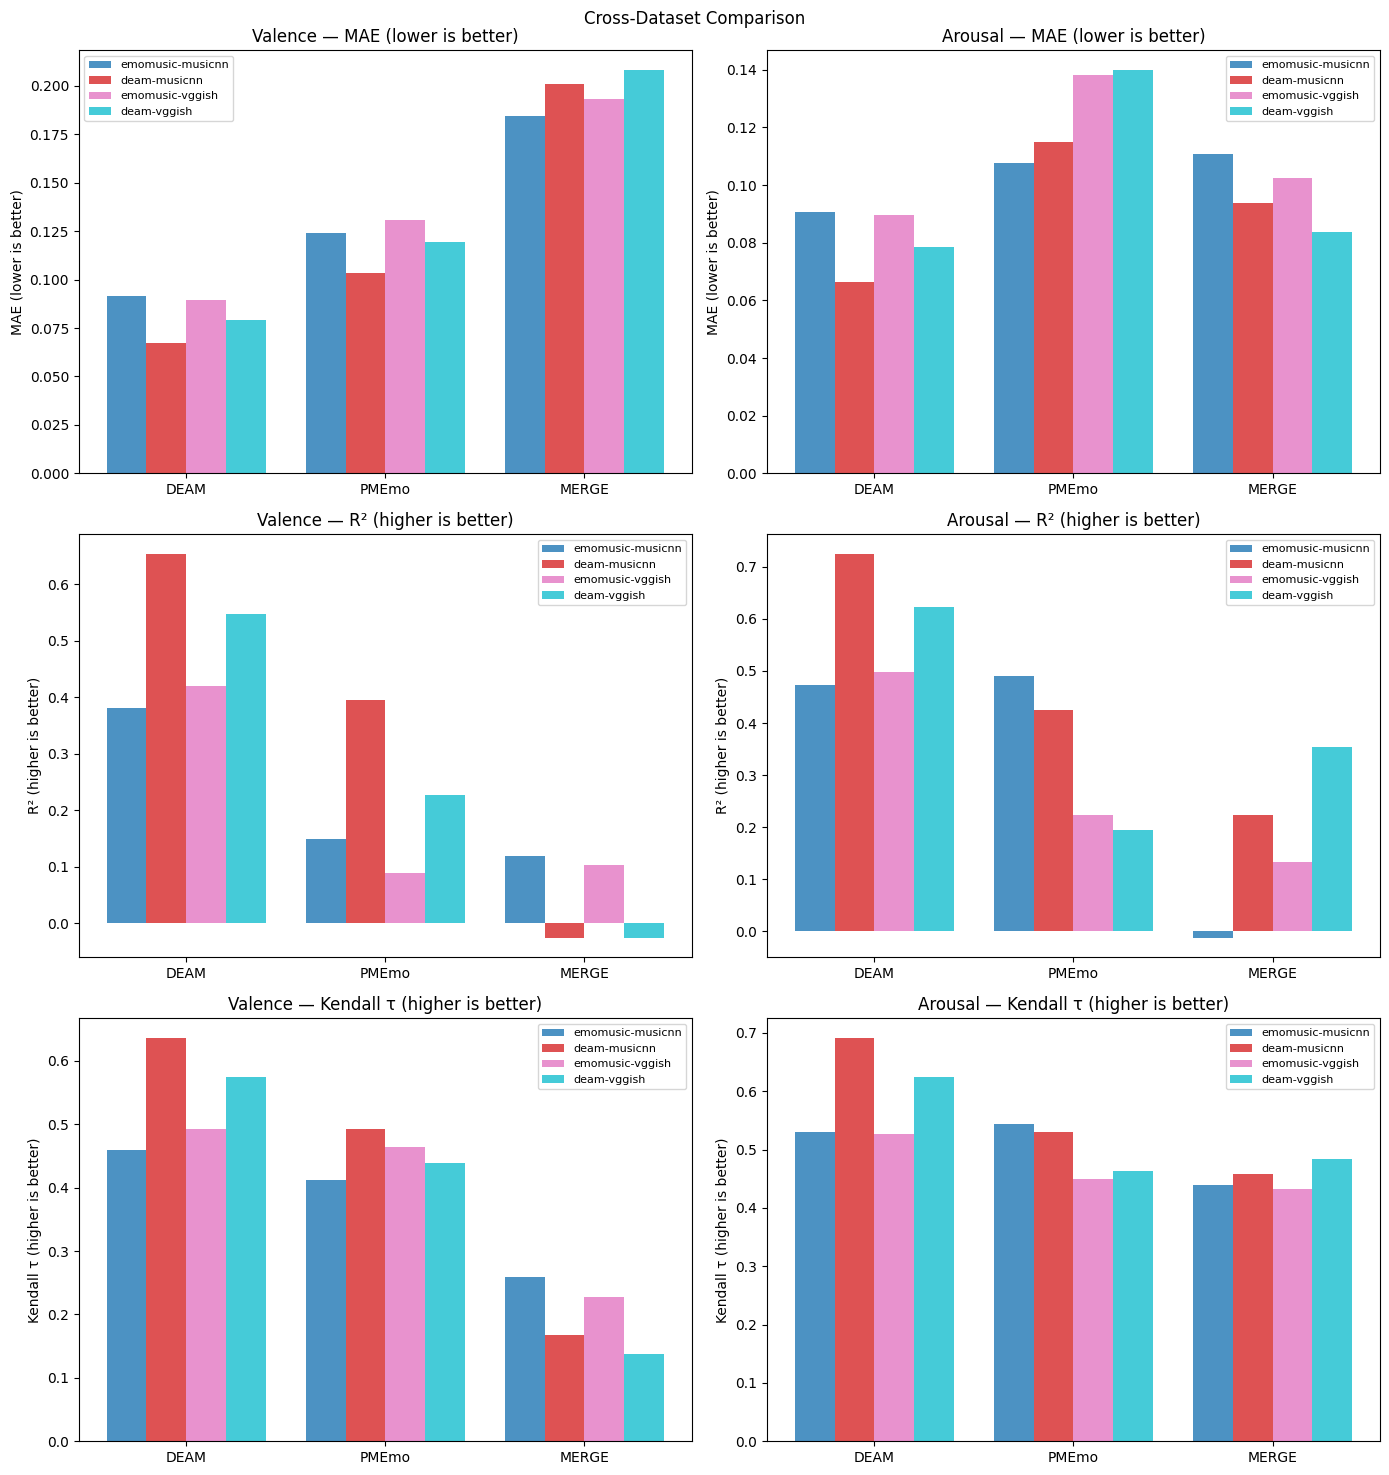

Saved: cross_dataset_comparison.png


In [9]:
if not all_results:
    print("No results to plot.")
else:
    combined = pd.concat(all_results.values())
    cross_dataset_comparison(combined)

## 7. Save Results

In [10]:
if all_results:
    combined = pd.concat(all_results.values())
    out = "essentia_models_comparison_results.csv"
    combined.to_csv(out, index=False)
    print(f"Saved: {out}  ({len(combined)} rows, {combined['model'].nunique()} models, "
          f"{combined['dataset'].nunique()} datasets)")
else:
    print("No results to save — run Section 5 first.")

Saved: essentia_models_comparison_results.csv  (23204 rows, 4 models, 3 datasets)
